In [ ]:
import os
import sys
from pathlib import Path

# 切换到项目根目录
project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 开启自动重载，这样你修改 src 里的代码，Notebook 会自动同步
%load_ext autoreload
%autoreload 2

# 完美导入你的工具箱！
from src import config
from src import data_loader
from src import features

print("✅ 准备就绪，可以开始 EDA！")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 准备就绪，可以开始 EDA！


[autoreload of src.features failed: Traceback (most recent call last):
  File "d:\codes\march_mania\march_mania\venv\lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "d:\codes\march_mania\march_mania\venv\lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "C:\Users\35551\.pyenv\pyenv-win\versions\3.10.11\lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "d:\codes\march_mania\march_mania\src\features.py", line 46, in <module>
    config = _import_config()
  File "d:\codes\march_mania\march_mania\src\features.py", line 43, in _import_config
    import config
ModuleNotFoundError: No module named 'config'
]


In [ ]:
regular_results, tourney_results, seeds = data_loader.get_main_datasets(True)
# 统计每列的缺失值绝对数量
missing_counts = tourney_results.isnull().sum()

# 仅打印那些确实存在缺失值的列，让界面更清爽
print(missing_counts[missing_counts > 0])

regular_results, tourney_results, seeds = features.process_after_year(regular_results, tourney_results, seeds)

Series([], dtype: int64)


In [ ]:
import pandas as pd
import numpy as np

take one team to see its journey during 2025 season

In [ ]:
season = 2025
rand_team_id = seeds['TeamID'].iat[np.random.randint(0, len(seeds))]

r = regular_results.loc[
    (regular_results['Season'] == season)
    &
    (
        (regular_results['WTeamID'] == rand_team_id)
        |
        (regular_results['LTeamID'] == rand_team_id)
    )
]

t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & 
    (
        (tourney_results["WTeamID"] == rand_team_id) 
        | 
        (tourney_results["LTeamID"] == rand_team_id)
    )
]

r["win"] = np.where(r["WTeamID"] == rand_team_id, "win", "lose")
t["win"] = np.where(t["WTeamID"] == rand_team_id, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
print(seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == rand_team_id)])
rt[["Season", "DayNum", "WTeamID", "LTeamID", "WScore", "LScore", "type", "win"]]

Empty DataFrame
Columns: [Season, Seed, TeamID]
Index: []


C:\Users\35551\AppData\Local\Temp\ipykernel_24984\4279496767.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r["win"] = np.where(r["WTeamID"] == rand_team_id, "win", "lose")
C:\Users\35551\AppData\Local\Temp\ipykernel_24984\4279496767.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r["type"] = "regular season"


,Season,DayNum,WTeamID,LTeamID,WScore,LScore,type,win
113346,2025,0,1439,1175,83,60,regular season,win
113468,2025,4,1439,1367,93,74,regular season,win
113574,2025,7,1439,1457,58,52,regular season,win
113722,2025,11,1336,1439,86,64,regular season,lose
113929,2025,16,1239,1439,74,64,regular season,lose
114197,2025,21,1276,1439,75,63,regular season,lose
114322,2025,23,1376,1439,70,60,regular season,lose
114610,2025,30,1435,1439,80,64,regular season,lose
114718,2025,33,1338,1439,64,59,regular season,lose
114849,2025,38,1439,1299,95,67,regular season,win


In [ ]:
regular_data = features.prepare_dataset(regular_results)
tourney_data = features.prepare_dataset(tourney_results)
# 统计每列的缺失值绝对数量
missing_counts = tourney_data.isnull().sum()

# 仅打印那些确实存在缺失值的列，让界面更清爽
print(missing_counts[missing_counts > 0])

Is_Home_Win    2410
dtype: int64


let's take an example match to double check if the same match is entered correctly in our dataset

In [ ]:
len(tourney_data)

4820

In [ ]:
t1, t2 = regular_data.loc[2,"T1_TeamID"], regular_data.loc[10,"T1_TeamID"]
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[(match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,...,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Poss,T2_Poss,PointDiff,Win,Gender,Is_Home_Win
57159,2014,57,1266,49.0,1166,67.0,0,19.0,53.0,2.0,...,13.0,3.0,4.0,18.0,63.900,63.600,18.0,1,1,H
59421,2014,107,1266,70.0,1166,85.0,0,24.0,52.0,2.0,...,11.0,2.0,4.0,30.0,65.450,66.100,15.0,1,1,A
63142,2015,72,1166,52.0,1266,53.0,0,20.0,55.0,7.0,...,15.0,6.0,4.0,10.0,59.700,59.800,1.0,1,1,H
64576,2015,103,1266,70.0,1166,77.0,0,23.0,58.0,9.0,...,16.0,5.0,2.0,19.0,64.500,66.925,7.0,1,1,H
69932,2016,103,1266,62.0,1166,65.0,0,24.0,54.0,5.0,...,8.0,5.0,1.0,15.0,68.225,69.125,3.0,1,1,A
70475,2016,114,1166,61.0,1266,66.0,0,26.0,59.0,3.0,...,13.0,9.0,2.0,16.0,66.700,68.225,5.0,1,1,A
74358,2017,82,1166,94.0,1266,102.0,0,33.0,68.0,11.0,...,14.0,6.0,7.0,17.0,79.400,79.975,8.0,1,1,A
76337,2017,124,1166,83.0,1266,91.0,0,33.0,68.0,8.0,...,14.0,10.0,4.0,14.0,76.075,78.750,8.0,1,1,H
81095,2018,110,1166,86.0,1266,90.0,0,32.0,57.0,11.0,...,12.0,5.0,1.0,15.0,68.225,68.125,4.0,1,1,A
81757,2018,124,1166,81.0,1266,85.0,0,31.0,70.0,11.0,...,13.0,1.0,5.0,13.0,70.550,69.650,4.0,1,1,H


In [ ]:
tourney_data=features.merge_seeds_and_tourney(tourney_data, seeds)

In [ ]:
import matplotlib.pyplot as plt

# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="Gender", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="Gender", index="T1_seed", values="PointDiff", aggfunc="std").ffill()


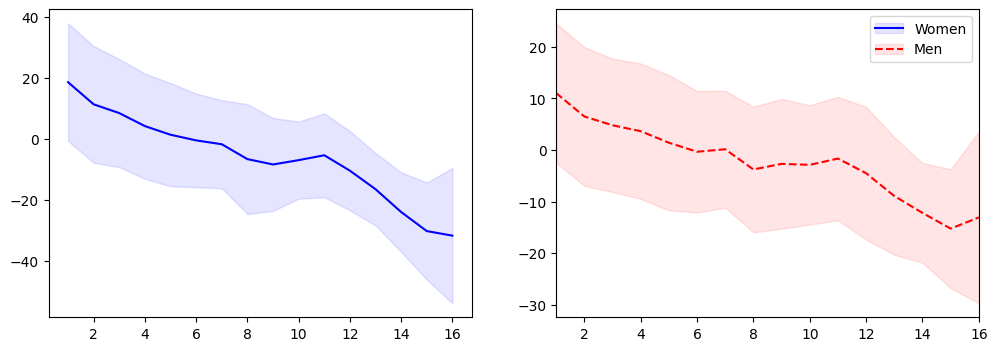

In [ ]:
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

In [ ]:
tmpmean = tourney_data.pivot_table(columns="Gender", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="Gender", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()

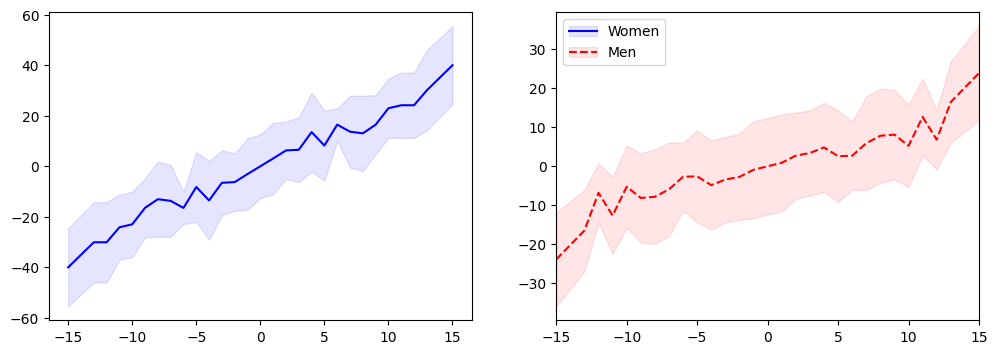

In [ ]:
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

In [ ]:
tourney_data.columns

Index(['Season', 'DayNum', 'T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA',
       'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF',
       'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR',
       'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Poss',
       'T2_Poss', 'PointDiff', 'Win', 'Gender', 'Is_Home_Win', 'T1_seed',
       'T2_seed', 'Seed_diff'],
      dtype='object')

获取所有列的相关热力图

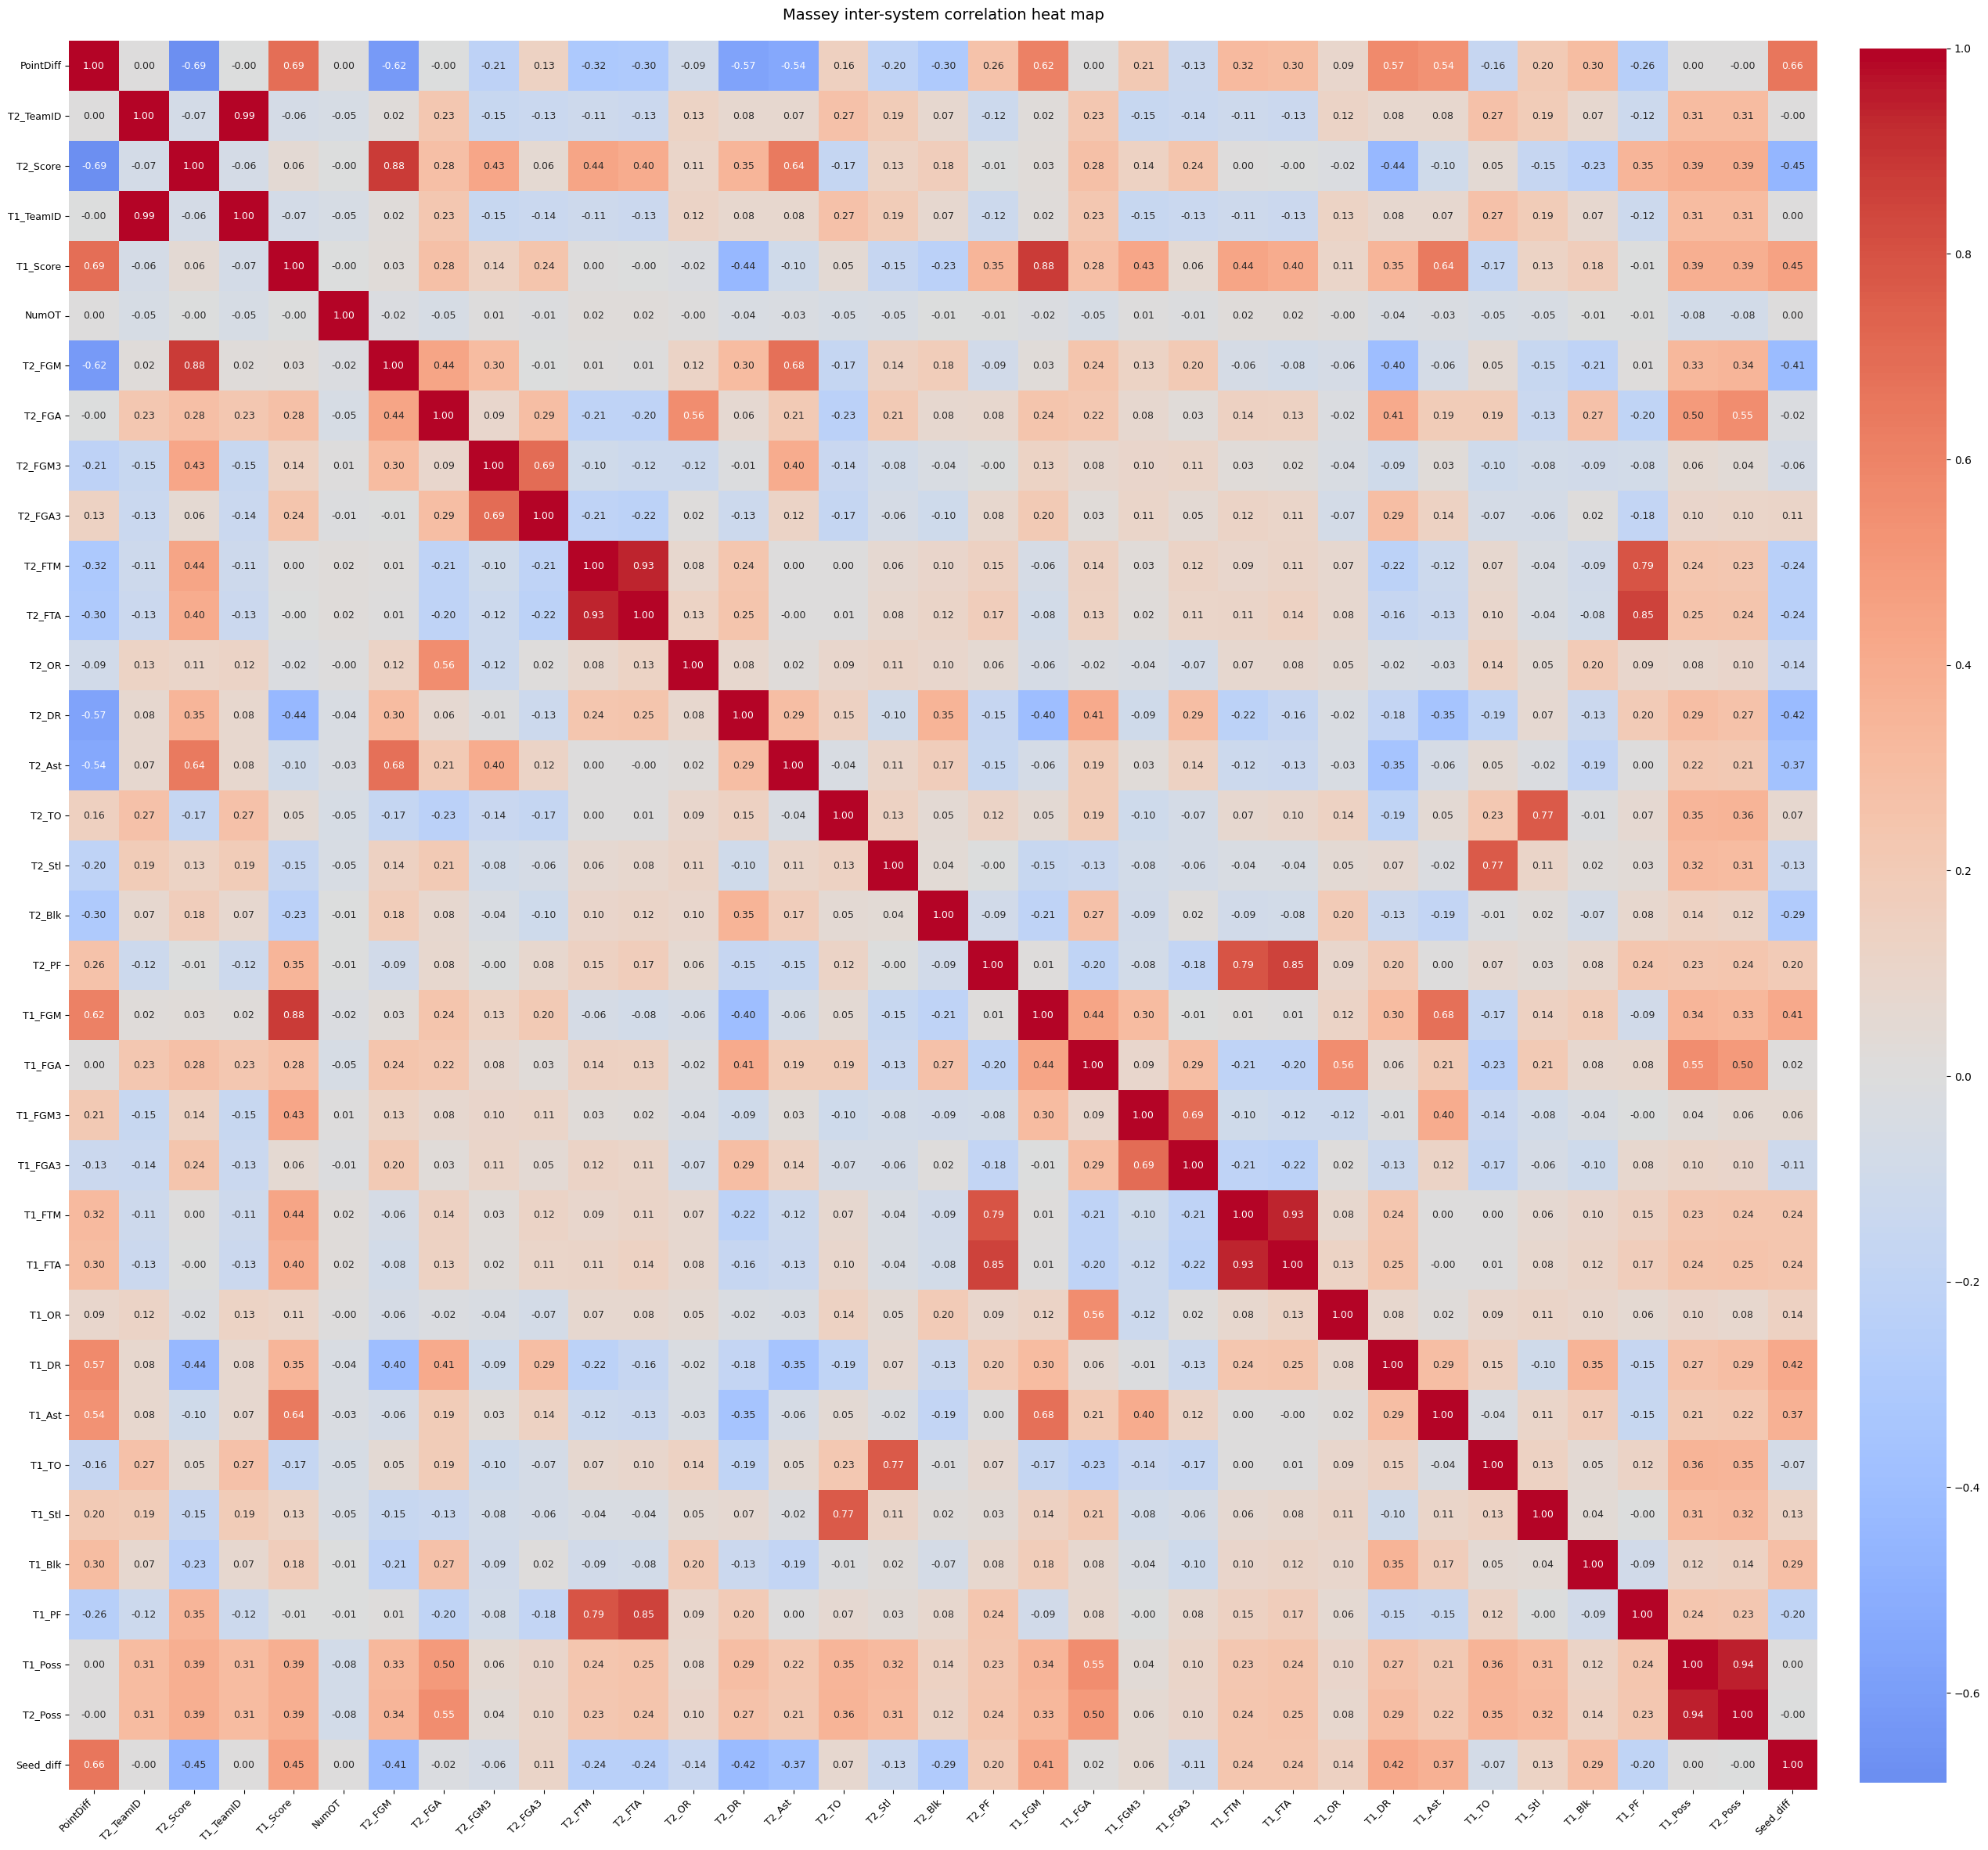

In [ ]:
cols = ['PointDiff','T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA',
       'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF',
       'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR',
       'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Poss',
       'T2_Poss',  'Seed_diff']
corr_matrix = tourney_data[cols].corr()
import seaborn as sns
import matplotlib.pyplot as plt
n_features = len(corr_matrix.columns)
# 每个格子约 0.8 英寸，留出边距
plt.figure(figsize=(max(12, n_features * 0.8), max(10, n_features * 0.8)))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            annot_kws={"size": max(6, 10 - n_features//20)},  # 特征越多字体略小
            square=True,          # 强制格子为正方形
            cbar_kws={"shrink": 0.8, "pad": 0.02})
plt.title('Massey inter-system correlation heat map', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('massey_corr_heatmap1.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
tourney_data = features.get_regular_mean(tourney_data ,regular_data)

In [ ]:
tourney_data.columns

Index(['Season', 'DayNum', 'T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA',
       'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF',
       'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR',
       'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Poss',
       'T2_Poss', 'PointDiff', 'Win', 'Gender', 'Is_Home_Win', 'T1_seed',
       'T2_seed', 'Seed_diff', 'T1_avg_Score', 'T1_avg_FGM', 'T1_avg_FGA',
       'T1_avg_FGM3', 'T1_avg_FGA3', 'T1_avg_FTM', 'T1_avg_FTA', 'T1_avg_OR',
       'T1_avg_DR', 'T1_avg_Ast', 'T1_avg_TO', 'T1_avg_Stl', 'T1_avg_Blk',
       'T1_avg_PF', 'T1_avg_PointDiff', 'T2_avg_Score', 'T2_avg_FGM',
       'T2_avg_FGA', 'T2_avg_FGM3', 'T2_avg_FGA3', 'T2_avg_FTM', 'T2_avg_FTA',
       'T2_avg_OR', 'T2_avg_DR', 'T2_avg_Ast', 'T2_avg_TO', 'T2_avg_Stl',
       'T2_avg_Blk', 'T2_avg_PF', 'T2_avg_PointDiff'],
      dtype='object')

In [ ]:
tourney_data = features.get_elo_rating(tourney_data, regular_data)

In [ ]:
tourney_data.columns

Index(['Season', 'DayNum', 'T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA',
       'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF',
       'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR',
       'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Poss',
       'T2_Poss', 'PointDiff', 'Win', 'Gender', 'Is_Home_Win', 'T1_seed',
       'T2_seed', 'Seed_diff', 'T1_avg_Score', 'T1_avg_FGM', 'T1_avg_FGA',
       'T1_avg_FGM3', 'T1_avg_FGA3', 'T1_avg_FTM', 'T1_avg_FTA', 'T1_avg_OR',
       'T1_avg_DR', 'T1_avg_Ast', 'T1_avg_TO', 'T1_avg_Stl', 'T1_avg_Blk',
       'T1_avg_PF', 'T1_avg_PointDiff', 'T2_avg_Score', 'T2_avg_FGM',
       'T2_avg_FGA', 'T2_avg_FGM3', 'T2_avg_FGA3', 'T2_avg_FTM', 'T2_avg_FTA',
       'T2_avg_OR', 'T2_avg_DR', 'T2_avg_Ast', 'T2_avg_TO', 'T2_avg_Stl',
       'T2_avg_Blk', 'T2_avg_PF', 'T2_avg_PointDiff', 'T1_elo', 'T2_elo',
       'elo_diff'],


In [ ]:
# 统计每列的缺失值绝对数量
missing_counts = tourney_data.isnull().sum()

# 仅打印那些确实存在缺失值的列，让界面更清爽
print(missing_counts[missing_counts > 0])

Is_Home_Win    2410
dtype: int64


In [ ]:
tourney_data.loc[0:10,'Is_Home_Win']

0     N
1     N
2     N
3     N
4     N
5     N
6     N
7     N
8     N
9     N
10    N
Name: Is_Home_Win, dtype: object